In [ ]:
!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-01-04 13:45:59--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.02MB/s    in 2m 39s  

2026-01-04 13:48:39 (5.17 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



In [32]:
import zipfile
from google.colab import drive
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [42]:
ZF = '/content/archive (6).zip'
ZR = zipfile.ZipFile(ZF, 'r')
ZR.extractall('/content/dataset')
ZR.close()

In [43]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
data_path = "/content/dataset/Emails.csv"
data = pd.read_csv(data_path)
texts = data["text"].values
labels = data["spam"].values

In [46]:
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [47]:
data.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


In [48]:
data.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [49]:
#Change the classes to 0-1
le = LabelEncoder()
labels = le.fit_transform(labels)

<Axes: ylabel='count'>

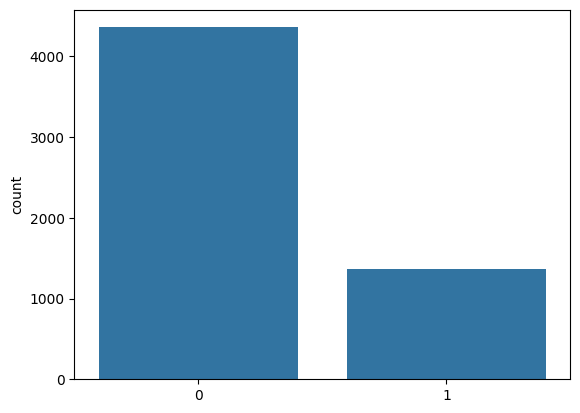

In [50]:
#Check if the classes ghange to 0-1(1-spam, 0-not spam)
sns.countplot(x = labels, data = data)

In [51]:
vocab_size = 1000
max_len = 100


tokenizer = Tokenizer(num_words = vocab_size, oov_token = "<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen = max_len, padding = "post", truncating = "post")

x_train, x_temp, y_train, y_temp = train_test_split(padded, labels, test_size = 0.2, random_state = 42)

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size = 0.5, random_state = 42)


In [52]:
#Because the data is imbalanced

class_weights = compute_class_weight(class_weight = "balanced",classes = np.unique(y_train), y = y_train)
class_weights_dic = dict(enumerate(class_weights))

In [53]:
#load pre_trained embedding(GloVe)

emb_dim = 100
embedding_index = {}

if os.path.exists("glove.6B.100d.txt"):
 with open("glove.6B.100d.txt", encoding = "utf8") as f:
   for line in f:
     values = line.split()
     word = values[0]
     embedding = np.asarray(values[1:], dtype = "float32")
     embedding_index[word] = embedding

     embedding_matrix = np.zeros((vocab_size, emb_dim))


     for word, i in tokenizer.word_index.items():
       if i < vocab_size:
         vec = embedding_index.get(word)
         if vec is not None:
           embedding_matrix[i] = vec


In [54]:
#CallBacks
e_stop = EarlyStopping(monitor = "val_loss", patience =3, restore_best_weights = True)

In [55]:
model_A = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 100, input_length = max_len),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])


model_A.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

history_A = model_A.fit(x_train, y_train, epochs = 15, batch_size = 32, validation_data = (x_val, y_val),
             class_weight = class_weights_dic)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.6859 - loss: 0.6329 - val_accuracy: 0.6702 - val_loss: 0.6290
Epoch 2/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.7434 - loss: 0.5586 - val_accuracy: 0.7609 - val_loss: 0.4186
Epoch 3/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.8172 - loss: 0.3258 - val_accuracy: 0.5009 - val_loss: 0.6711
Epoch 4/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.6532 - loss: 0.5246 - val_accuracy: 0.9494 - val_loss: 0.1785
Epoch 5/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.9224 - loss: 0.2258 - val_accuracy: 0.9721 - val_loss: 0.1052
Epoch 6/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9688 - loss: 0.1043 - val_accuracy: 0.8220 - val_loss: 0.5822
Epoch 7/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8639 - loss: 0.2801 - val_accuracy: 0.9756 - val_loss: 0.0810
Epoch 8/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9823 - loss: 0.0579 - va

In [56]:
model_A_T = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, emb_dim, weights=[embedding_matrix], trainable = False),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_A_T.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

history_A_T = model_A_T.fit(x_train, y_train, epochs = 15, batch_size = 32, validation_data = (x_val, y_val),
               class_weight = class_weights_dic)

Epoch 1/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.6397 - loss: 0.6536 - val_accuracy: 0.8429 - val_loss: 0.3793
Epoch 2/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7269 - loss: 0.6345 - val_accuracy: 0.7120 - val_loss: 0.5600
Epoch 3/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.6463 - loss: 0.5570 - val_accuracy: 0.8080 - val_loss: 0.3900
Epoch 4/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.6823 - loss: 0.4911 - val_accuracy: 0.8639 - val_loss: 0.3033
Epoch 5/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.8714 - loss: 0.3133 - val_accuracy: 0.9302 - val_loss: 0.2107
Epoch 6/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9136 - loss: 0.2268 - val_accuracy: 0.9407 - val_loss: 0.1488
Epoch 7/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9263 - loss: 0.1781 - val_accuracy: 0.9389 - val_loss: 0.1985
Epoch 8/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9357 - loss: 0.1521 - val

In [57]:
model_B = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 100),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_B.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

history_B = model_B.fit(x_train, y_train, epochs = 15, batch_size = 32, validation_data = (x_val, y_val),
             class_weight = class_weights_dic)

Epoch 1/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - accuracy: 0.7070 - loss: 0.4482 - val_accuracy: 0.9459 - val_loss: 0.1397
Epoch 2/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.9668 - loss: 0.0931 - val_accuracy: 0.9721 - val_loss: 0.1017
Epoch 3/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.9809 - loss: 0.0713 - val_accuracy: 0.9791 - val_loss: 0.0528
Epoch 4/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step - accuracy: 0.9918 - loss: 0.0230 - val_accuracy: 0.9738 - val_loss: 0.0795
Epoch 5/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 128ms/step - accuracy: 0.9878 - loss: 0.0418 - val_accuracy: 0.9860 - val_loss: 0.0474
Epoch 6/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.9983 - loss: 0.0077 - val_accuracy: 0.9825 - val_loss: 0.0552
Epoch 7/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.9941 - loss: 0.0144 - val_accuracy: 0.9791 - val_loss: 0.0569
Epoch 8/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9959 - loss: 0

In [58]:
model_B_T = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, emb_dim, weights = [embedding_matrix], trainable = False),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_B_T.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

history_B_T = model_B_T.fit(x_train, y_train, epochs = 15, batch_size = 32, validation_data = (x_val, y_val),
              class_weight = class_weights_dic)

Epoch 1/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.7479 - loss: 0.5006 - val_accuracy: 0.9197 - val_loss: 0.2050
Epoch 2/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.8968 - loss: 0.2370 - val_accuracy: 0.9337 - val_loss: 0.1667
Epoch 3/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.9404 - loss: 0.1584 - val_accuracy: 0.9564 - val_loss: 0.1125
Epoch 4/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9468 - loss: 0.1300 - val_accuracy: 0.9407 - val_loss: 0.1376
Epoch 5/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9471 - loss: 0.1251 - val_accuracy: 0.9668 - val_loss: 0.0717
Epoch 6/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.9713 - loss: 0.0767 - val_accuracy: 0.9686 - val_loss: 0.0677
Epoch 7/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9593 - loss: 0.0956 - val_accuracy: 0.9686 - val_loss: 0.0724
Epoch 8/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.9787 - loss: 0.054

In [59]:
#evaluation

models = {
    "A_scratch": (model_A, history_A),
    "A_Transfer": (model_A_T, history_A_T),
    "B_scratch": (model_B, history_B),
    "B_transfer": (model_B_T, history_B_T)
}

for n, (m,h) in models.items():
  loss, acc = m.evaluate(x_test, y_test)
  probs = m.predict(x_test).ravel()
  preds = (probs > 0.5).astype(int)

  print(f"\n{n}")
  print("Accuracy: ", acc)
  print("F1_score: ", f1_score(y_test, preds))
  print("ROC_AUC: ", roc_auc_score(y_test, probs))
  print("Confusion Matrix:\n ", confusion_matrix(y_test,preds))



18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8728 - loss: 0.3436
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

A_scratch
Accuracy:  0.8848167657852173
F1_score:  0.7987804878048781
ROC_AUC:  0.9347853736089031
Confusion Matrix:
  [[376  49]
 [ 17 131]]
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9483 - loss: 0.1062
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

A_Transfer
Accuracy:  0.9528796076774597
F1_score:  0.912621359223301
ROC_AUC:  0.9921780604133545
Confusion Matrix:
  [[405  20]
 [  7 141]]
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9811 - loss: 0.1386
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step

B_scratch
Accuracy:  0.9790576100349426
F1_score:  0.958904109589041
ROC_AUC:  0.9907631160572338
Confusion Matrix:
  [[421   4]
 [  8 140]]
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9720 - loss: 0.0928
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step

B_transfer
Accuracy:  0.9773123860359192
F1_score:  0.9559322033898305
ROC_AUC:  0.9971224165341812
Confusion Matri